# 2. Vocabulary and Semantic Diversity  
**Why**: If the generated texts are too formulaic (e.g., every description repeats “premium comfort running shoe”), embeddings may collapse toward a small region in vector space. It tells us how rich and varied the text is, which directly affects embeddings and vector search quality.

**Why It Matters for Vector Search**

Documents with low vocabulary/semantic diversity often produce embeddings that are less distinguishable, making nearest-neighbor search less precise.
Diverse vocabulary → embeddings capture richer context → better differentiation in vector space.
This also helps detect “boring” or boilerplate docs that add little value.

Compute:

Type–token ratio (unique words / total words)

Shannon entropy of term frequency distribution

Cosine similarity mean/std between randomly sampled embeddings (once you embed a subset)

Action:

Adjust few-shot examples or temperature if variance is too low.

✅ Notebook Features

✔ Uses intfloat/e5-small  
✔ Computes TTR, vocabulary size, semantic diversity  
✔ Flags low-quality (repetitive / low-diversity) docs  

In [1]:
# ===============================================================
# 📌 Imports
# ===============================================================

from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm


In [8]:
# ===============================================================
# 📌 Load E5-small (English-only)
# ===============================================================

model = SentenceTransformer("intfloat/e5-small")


In [3]:
# ===============================================================
# 📌 Helper Functions
# ===============================================================

def tokenize(doc):
    """Simple whitespace tokenizer."""
    return doc.lower().split()


In [4]:
def type_token_ratio(tokens):
    """Compute TTR (unique tokens / total tokens)."""
    return len(set(tokens)) / len(tokens)


In [5]:
def compute_semantic_diversity(tokens, model):
    """
    Semantic Diversity = Average pairwise cosine distance
    across all unique token embeddings.

    Higher = richer semantic content.
    Lower = narrow or repetitive content.
    """
    unique_tokens = list(set(tokens))

    if len(unique_tokens) < 3:
        return 0.0  # not enough material for semantic diversity

    # E5 expects prefix "query: " for embedding queries
    queries = [f"query: {tok}" for tok in unique_tokens]

    embeddings = model.encode(
        queries,
        normalize_embeddings=True,
        batch_size=64
    )

    # Pairwise cosine similarity matrix
    sim = embeddings @ embeddings.T

    # Convert to distances
    dist = 1 - sim

    # Extract upper-triangle values (excluding diagonal)
    upper = dist[np.triu_indices(len(dist), k=1)]

    return float(np.mean(upper))


In [6]:
# ---------------------------------
# 1. Load CSV
# ---------------------------------
docs = pd.read_csv("~/work/vector_search/llm_prod_desc_analysis/llm_generated_prod_desc.csv")   # columns: ecode, llm_description_few_shot

# Rename for convenience
docs = docs.rename(columns={"llm_description_few_shot": "text"})

# Drop missing rows
docs = docs.dropna(subset=["text"])

print(f"Loaded {len(docs)} descriptions")


Loaded 179965 descriptions


In [7]:
import re

def split_into_sentences(text):
    # Simple English sentence splitter
    return re.split(r'(?<=[.!?])\s+', text.strip())


✅ Sentence-Level Semantic Diversity

(More robust than token-level)

In [8]:
def compute_sentence_semantic_diversity(text, model):
    """
    Computes average pairwise cosine distance of sentence embeddings.
    Higher = more semantic variety across ideas.
    """
    sentences = split_into_sentences(text)

    # Ignore tiny documents
    if len(sentences) < 2:
        return 0.0

    queries = [f"query: {s}" for s in sentences]

    embeddings = model.encode(
        queries,
        normalize_embeddings=True,
        batch_size=16
    )

    sim = embeddings @ embeddings.T
    dist = 1 - sim

    upper = dist[np.triu_indices(len(dist), k=1)]
    return float(np.mean(upper))


In [9]:
# ===============================================================
# 📌 Run Vocabulary + Semantic Diversity Analysis
# ===============================================================

results = []

for idx, row in tqdm(docs.iterrows(), total=len(docs)):
    doc = str(row["text"])  # text column in your CSV
    
    tokens = tokenize(doc)
    sentences = split_into_sentences(doc)

    ttr = type_token_ratio(tokens)
    vocab_size = len(set(tokens))
    total_tokens = len(tokens)

    # Token-level semantic diversity (optional)
    token_semantic_div = compute_semantic_diversity(tokens, model)

    # Sentence-level semantic diversity (recommended)
    sentence_semantic_div = compute_sentence_semantic_diversity(doc, model)

    results.append({
        "id": row.get("id", idx),  # handles ID if present
        "document_preview": doc[:60] + "...",
        "tokens": total_tokens,
        "vocab_size": vocab_size,
        "TTR": round(ttr, 3),
        "semantic_diversity_tokens": round(token_semantic_div, 3),
        "semantic_diversity_sentences": round(sentence_semantic_div, 3),
        "num_sentences": len(sentences),
    })

df = pd.DataFrame(results)
df


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 179965/179965 [2:00:25<00:00, 24.91it/s]


,id,document_preview,tokens,vocab_size,TTR,semantic_diversity_tokens,semantic_diversity_sentences,num_sentences
0,0,The FOCO Men's Detroit Red Wings Multicolor Ho...,88,63,0.716,0.164,0.183,5
1,1,The Logo Athletic Men's Georgia Bulldogs Red/B...,83,61,0.735,0.165,0.168,5
2,2,The Logo Athletic Men's Kansas Jayhawks Royal/...,87,65,0.747,0.167,0.155,5
3,3,The Logo Athletic Men's Kansas State Wildcats ...,81,61,0.753,0.163,0.167,5
4,4,The Logo Athletic Men's LSU Tigers Purple/Gold...,80,61,0.762,0.166,0.165,5
...,...,...,...,...,...,...,...,...
179960,179960,The FOCO Men's Philadelphia Phillies Red Ugly ...,82,57,0.695,0.162,0.173,5
179961,179961,The FOCO Men's Michigan Wolverines Blue Ugly K...,80,58,0.725,0.165,0.174,5
179962,179962,The FOCO Men's Tampa Bay Buccaneers Red Ugly K...,93,65,0.699,0.165,0.168,5
179963,179963,The FOCO Men's Cincinnati Bengals Orange Ugly ...,86,62,0.721,0.166,0.178,5


In [10]:
# ===============================================================
# 📌 Flag Low-Diversity & Low-Vocab Documents
# ===============================================================
SEMANTIC_THRESHOLD = df["semantic_diversity_sentences"].quantile(0.10)
VOCAB_THRESHOLD = df["TTR"].quantile(0.10)   # bottom 10%

df["low_vocab_flag"] = df["TTR"] < VOCAB_THRESHOLD
df["low_semantic_div_flag"] = df["semantic_diversity_sentences"] < SEMANTIC_THRESHOLD

# TTR: Only filter the bottom 5% (most severe repetition/low vocab)
VOCAB_THRESHOLD = df["TTR"].quantile(0.05)

# Semantic Diversity: Filter the bottom 10% (more aggressive on concept looping)
SEMANTIC_THRESHOLD = df["semantic_diversity_sentences"].quantile(0.10)

# Flagging
df["low_vocab_flag"] = df["TTR"] < VOCAB_THRESHOLD
df["low_semantic_div_flag"] = df["semantic_diversity_sentences"] < SEMANTIC_THRESHOLD

# Final Garbage Flag: A document is garbage if it fails EITHER test
df["is_garbage"] = df["low_vocab_flag"] | df["low_semantic_div_flag"]


In [11]:
# ===============================================================
# 📌 Filter "Clean" Documents for Embedding
# ===============================================================

clean_df = df[(df["low_vocab_flag"] == False) |
              (df["low_semantic_div_flag"] == False)]

clean_df.head()

,id,document_preview,tokens,vocab_size,TTR,semantic_diversity_tokens,semantic_diversity_sentences,num_sentences,low_vocab_flag,low_semantic_div_flag,is_garbage
0,0,The FOCO Men's Detroit Red Wings Multicolor Ho...,88,63,0.716,0.164,0.183,5,False,False,False
1,1,The Logo Athletic Men's Georgia Bulldogs Red/B...,83,61,0.735,0.165,0.168,5,False,False,False
2,2,The Logo Athletic Men's Kansas Jayhawks Royal/...,87,65,0.747,0.167,0.155,5,False,False,False
3,3,The Logo Athletic Men's Kansas State Wildcats ...,81,61,0.753,0.163,0.167,5,False,False,False
4,4,The Logo Athletic Men's LSU Tigers Purple/Gold...,80,61,0.762,0.166,0.165,5,False,False,False


In [12]:
#print(clean_df[clean_df["is_garbage"]])

In [13]:
df["low_vocab_flag"].value_counts()
df["low_semantic_div_flag"].value_counts()


False    162630
True      17335
Name: low_semantic_div_flag, dtype: int64

In [14]:
#!pip install seaborn

Visualization Section (Scatter Plots + Histograms)

Add this after df is created.

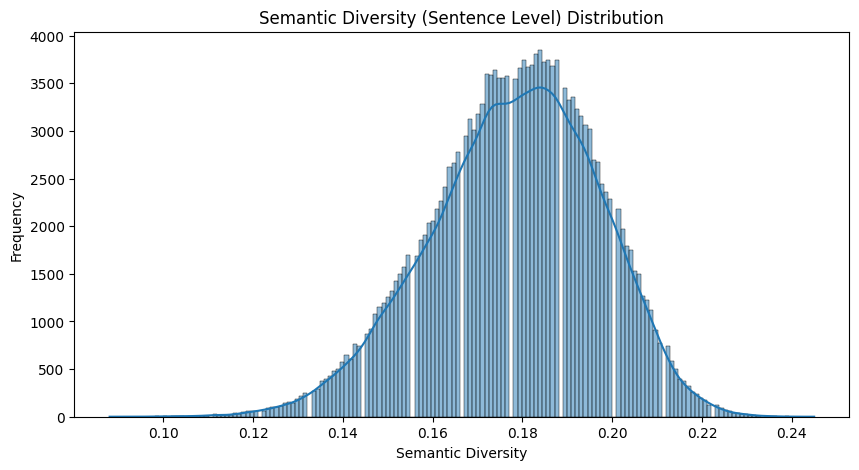

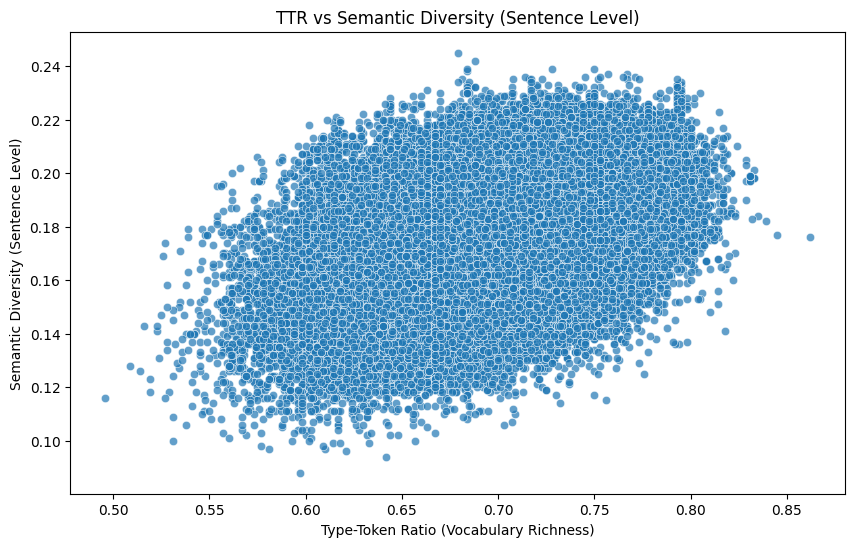

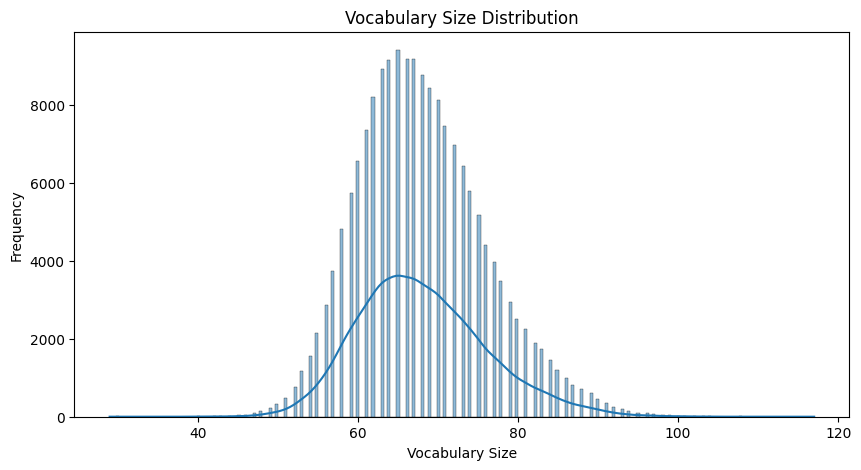

<Axes: >

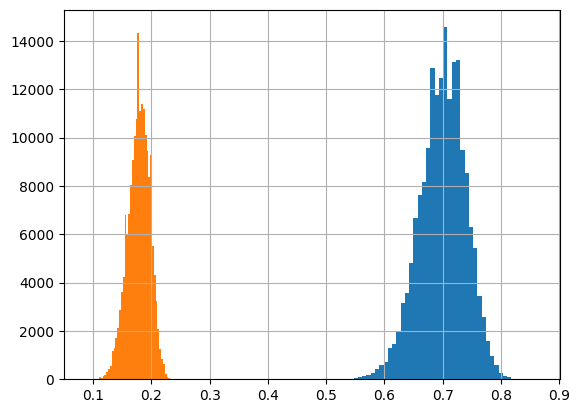

In [15]:
# ===============================================================
# 📊 Visualization
# ===============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# --------- Histogram of Sentence-Level Semantic Diversity ---------
plt.figure(figsize=(10,5))
sns.histplot(df["semantic_diversity_sentences"], kde=True)
plt.title("Semantic Diversity (Sentence Level) Distribution")
plt.xlabel("Semantic Diversity")
plt.ylabel("Frequency")
plt.savefig("semantic_diversity.png")
plt.show()

# --------- Scatter: TTR vs Sentence-Level Semantic Diversity ---------
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df["TTR"],
    y=df["semantic_diversity_sentences"],
    alpha=0.7
)
plt.title("TTR vs Semantic Diversity (Sentence Level)")
plt.xlabel("Type-Token Ratio (Vocabulary Richness)")
plt.ylabel("Semantic Diversity (Sentence Level)")
plt.savefig("ttr_semantic_diversity.png")
plt.show()

# --------- Histogram: Vocabulary Size ---------
plt.figure(figsize=(10,5))
sns.histplot(df["vocab_size"], kde=True)
plt.title("Vocabulary Size Distribution")
plt.xlabel("Vocabulary Size")
plt.ylabel("Frequency")
plt.savefig("vocab_size.png")
plt.show()


df["TTR"].hist(bins=50)
df["semantic_diversity_sentences"].hist(bins=50)


# Get lowest 10 semantic-diversity documents

In [16]:
# Sort ascending → lowest diversity first
lowest100 = df.nsmallest(10, "semantic_diversity_sentences")

lowest100[["document_preview", 
           "semantic_diversity_sentences", 
           "TTR", 
           "tokens"]]


,document_preview,semantic_diversity_sentences,TTR,tokens
49648,The EyeLine Golf Slide Guide Putting Setup Aid...,0.088,0.597,119
131485,The Postfly Fly Fishing Kit is a unisex produc...,0.094,0.642,123
79773,The Maxfli 2024 Vibes Towel is a unisex towel ...,0.096,0.621,95
36349,The Guardian Adult Mambo Snorkeling Mask is a ...,0.097,0.610,100
39343,The GK Elite Ion Cheer Sports Bra is a girls' ...,0.097,0.581,105
71652,The DSG Girls' High Waist Swim Bottoms are gir...,0.098,0.577,97
91367,The Thule UpRide Fatbike Adapter is a bike rac...,0.098,0.609,87
25587,The Good Good The Goodest Umbrella is a unisex...,0.099,0.614,88
105512,The Maxfli Ryder Cup Towel is a unisex towel f...,0.099,0.633,98
113253,The JOOLA Megalodon Junior Pickleball Paddle i...,0.099,0.618,123


# Bar Plot: 100 Lowest Semantic Diversity Docs

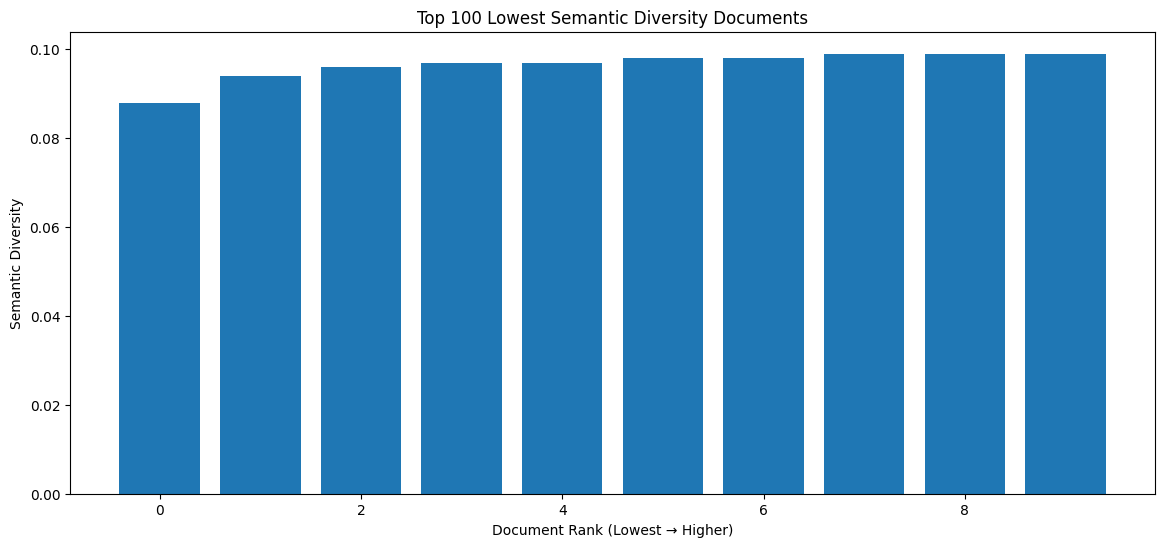

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))
plt.bar(
    np.arange(len(lowest100)), 
    lowest100["semantic_diversity_sentences"]
)
plt.title("Top 100 Lowest Semantic Diversity Documents")
plt.xlabel("Document Rank (Lowest → Higher)")
plt.ylabel("Semantic Diversity")
plt.show()


# Visualize document previews as a vertical plot  
This is extremely helpful for diagnosing repetitive patterns.

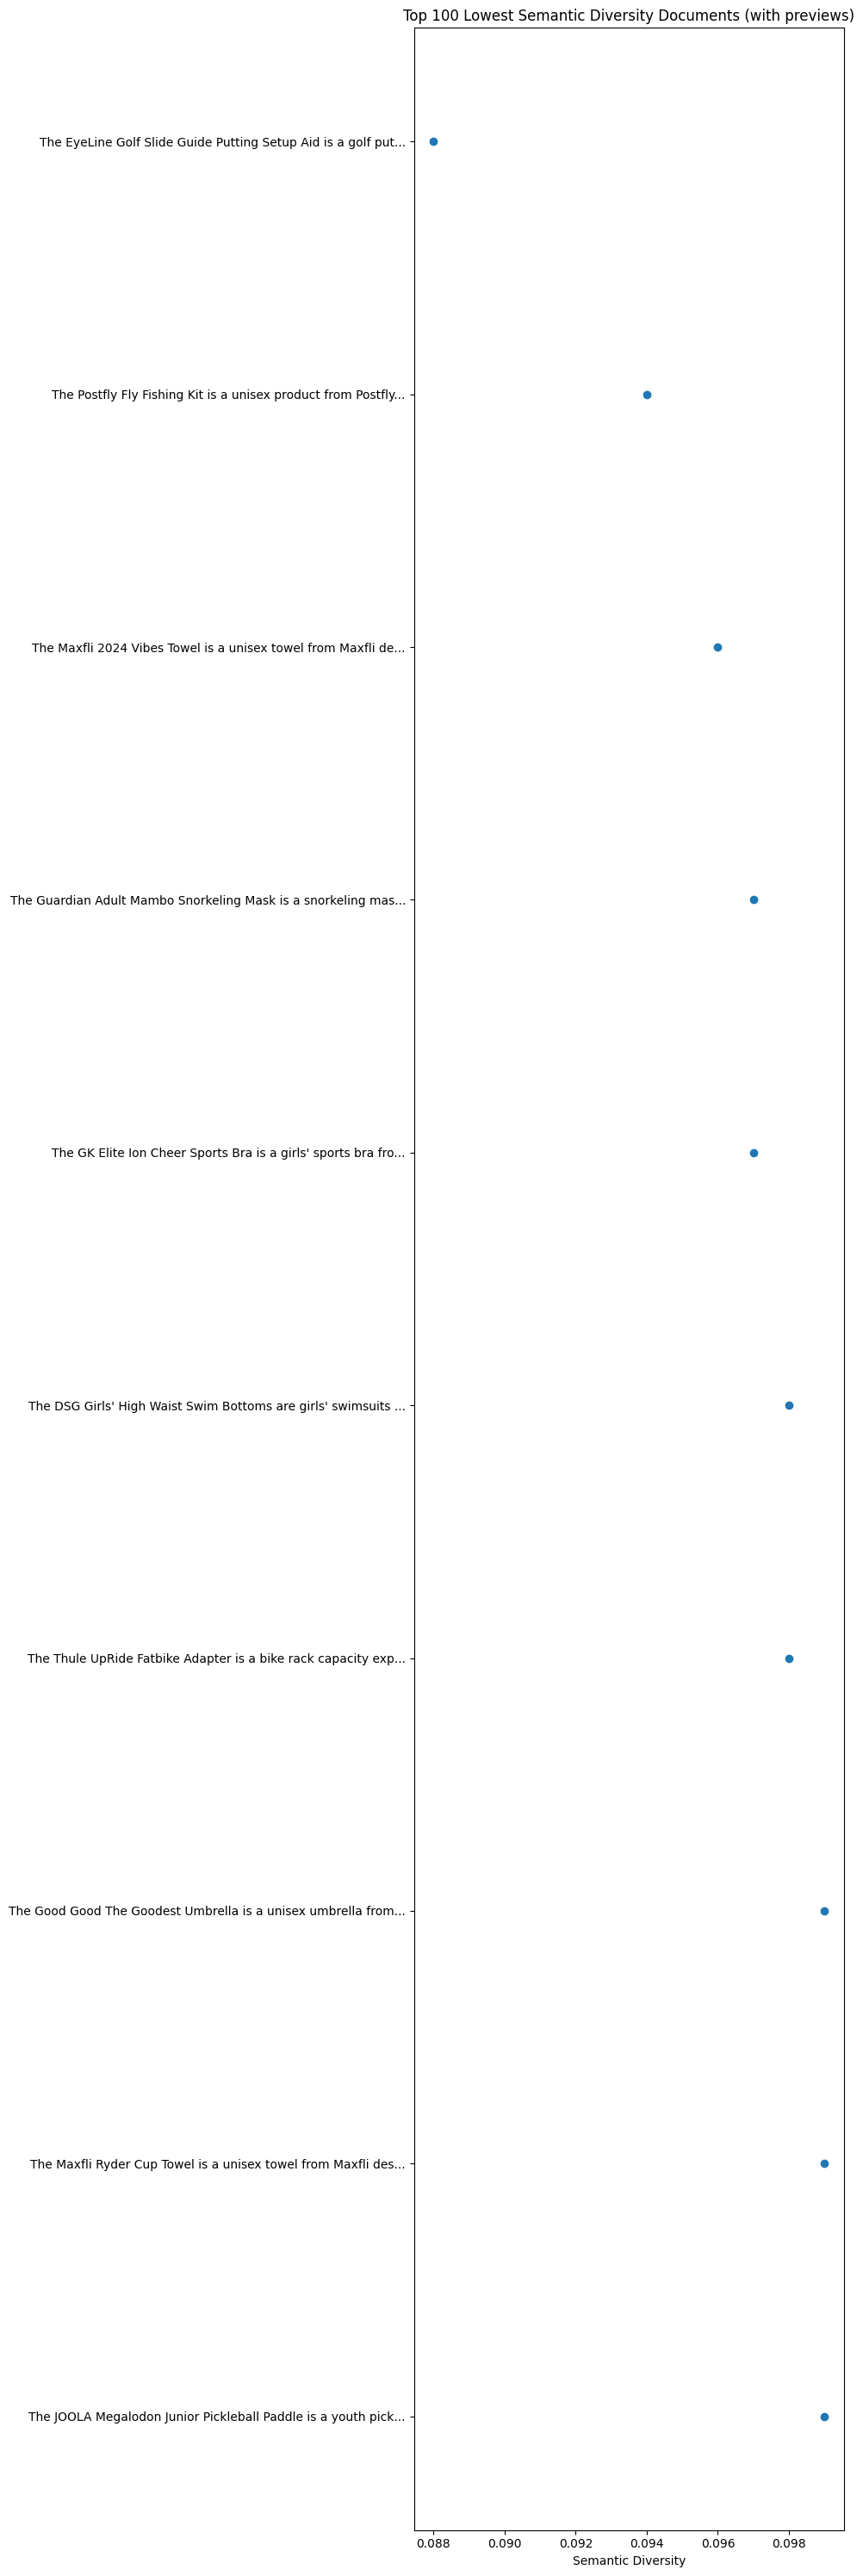

In [18]:
plt.figure(figsize=(10, 30))

y_pos = np.arange(len(lowest100))

plt.scatter(
    lowest100["semantic_diversity_sentences"],
    y_pos
)

plt.yticks(y_pos, lowest100["document_preview"])
plt.xlabel("Semantic Diversity")
plt.title("Top 100 Lowest Semantic Diversity Documents (with previews)")
plt.gca().invert_yaxis()   # smallest at top
plt.tight_layout()
plt.show()


In [19]:
# ===============================================================
# 📌 Export Results
# ===============================================================

df.to_csv("vocab_semantic_diversity_results.csv", index=False)
clean_df.to_csv("clean_docs_for_embedding.csv", index=False)


In [20]:
df.nsmallest(20, "semantic_diversity_sentences")


,id,document_preview,tokens,vocab_size,TTR,semantic_diversity_tokens,semantic_diversity_sentences,num_sentences,low_vocab_flag,low_semantic_div_flag,is_garbage
49648,49648,The EyeLine Golf Slide Guide Putting Setup Aid...,119,71,0.597,0.161,0.088,5,True,True,True
131485,131485,The Postfly Fly Fishing Kit is a unisex produc...,123,79,0.642,0.165,0.094,5,False,True,True
79773,79773,The Maxfli 2024 Vibes Towel is a unisex towel ...,95,59,0.621,0.168,0.096,5,True,True,True
36349,36349,The Guardian Adult Mambo Snorkeling Mask is a ...,100,61,0.610,0.171,0.097,5,True,True,True
39343,39343,The GK Elite Ion Cheer Sports Bra is a girls' ...,105,61,0.581,0.170,0.097,5,True,True,True
71652,71652,The DSG Girls' High Waist Swim Bottoms are gir...,97,56,0.577,0.166,0.098,5,True,True,True
91367,91367,The Thule UpRide Fatbike Adapter is a bike rac...,87,53,0.609,0.166,0.098,5,True,True,True
25587,25587,The Good Good The Goodest Umbrella is a unisex...,88,54,0.614,0.161,0.099,5,True,True,True
105512,105512,The Maxfli Ryder Cup Towel is a unisex towel f...,98,62,0.633,0.170,0.099,5,False,True,True
113253,113253,The JOOLA Megalodon Junior Pickleball Paddle i...,123,76,0.618,0.169,0.099,5,True,True,True


In [21]:
semantic_threshold = df["semantic_diversity_sentences"].quantile(0.10)
semantic_threshold

0.153

In [1]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm


In [2]:
# ---------------------------------
# 1. Load CSV
# ---------------------------------
docs = pd.read_csv("~/work/vector_search/llm_prod_desc_analysis/llm_generated_prod_desc.csv", nrows=60000)   # columns: ecode, llm_description_few_shot

# Rename for convenience
docs = docs.rename(columns={"llm_description_few_shot": "text"})

# Drop missing rows
docs = docs.dropna(subset=["text"])

print(f"Loaded {len(docs)} descriptions")


Loaded 60000 descriptions


### Embedding Stability

In [3]:
# ===============================================================
# 📌 Load E5-small (English-only)
# ===============================================================

model = SentenceTransformer("intfloat/e5-small")


In [4]:
def calculate_embedding_stability(descriptions, model, num_trials=3):
    """
    Test if slight paraphrasing produces similar embeddings
    (indicates robust semantic representation)
    """
    from sklearn.metrics.pairwise import cosine_similarity
    
    stability_scores = []
    
    for desc in descriptions:  
        embeddings = []
        
        # Generate embedding multiple times (with dropout if model supports it)
        for _ in range(num_trials):
            emb = model.encode(f"passage: {desc}")
            embeddings.append(emb)
        
        # Calculate pairwise similarities
        similarities = []
        for i in range(len(embeddings)):
            for j in range(i + 1, len(embeddings)):
                sim = cosine_similarity([embeddings[i]], [embeddings[j]])[0][0]
                similarities.append(sim)
        
        stability_scores.append(np.mean(similarities))
    
    return {
        'mean_stability': np.mean(stability_scores)
    }

# Target:
# Stability > 0.95: Very stable (good)

# Embedding Dispersion
Measures how well descriptions are distributed in embedding space.

In [5]:
def calculate_embedding_dispersion(descriptions, model):
    """
    Well-distributed embeddings = good semantic coverage
    Clustered embeddings = descriptions too similar
    """
    embeddings = model.encode([f"passage: {d}" for d in descriptions])
    
    # Calculate pairwise distances
    from sklearn.metrics.pairwise import euclidean_distances
    distances = euclidean_distances(embeddings)
    
    # Get upper triangle (unique pairs)
    upper_triangle = distances[np.triu_indices_from(distances, k=1)]
    
    return {
        'mean_distance': np.mean(upper_triangle),
        'std_distance': np.std(upper_triangle),
        'min_distance': np.min(upper_triangle),  # Closest pair
        'max_distance': np.max(upper_triangle)   # Farthest pair
    }

# Interpretation:
# High mean distance (>0.5): Descriptions are diverse
# Low mean distance (<0.3): Descriptions too similar
# Low std distance: Uniform distribution (good)
# High std distance: Some clusters, some outliers

### Embedding Dimensionality Usage

In [6]:
def calculate_dimensionality_usage(descriptions, model):
    """
    Check if embeddings use the full dimensional space
    (not collapsing to lower dimensions)
    """
    embeddings = model.encode([f"passage: {d}" for d in descriptions])
    
    # PCA to check effective dimensionality
    from sklearn.decomposition import PCA
    
    pca = PCA()
    pca.fit(embeddings)
    
    # Find number of components for 95% variance
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    n_components_95 = np.argmax(cumsum >= 0.95) + 1
    
    return {
        'effective_dimensions': n_components_95,
        'total_dimensions': embeddings.shape[1],
        'dimension_usage_ratio': n_components_95 / embeddings.shape[1]
    }

# Target:
# Usage ratio > 0.7: Good use of embedding space
# Usage ratio < 0.5: Descriptions too similar/simple

In [7]:
descriptions=docs['text'].to_list()

In [9]:
embedding_stability=calculate_embedding_stability(descriptions, model)
print(embedding_stability)

{'mean_stability': 1.0}


In [8]:
embedding_dispersion=calculate_embedding_dispersion(descriptions, model)
print(embedding_dispersion)

{'mean_distance': 0.5949772, 'std_distance': 0.046068136, 'min_distance': 0.0, 'max_distance': 0.7881019}


In [9]:
dimensionality_usage=calculate_dimensionality_usage(descriptions, model)
print(dimensionality_usage)

{'effective_dimensions': 263, 'total_dimensions': 384, 'dimension_usage_ratio': 0.6848958333333334}
